In [3]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import torch

In [4]:
#Calculus is the branch of mathematics that studies how things change. 
# It is used to find the rate of change of a function with respect to its input. 
# It is also used to find the area under a curve.

#A function is said to be differentiable at a point if it has a derivative at that point.
def f(x):
    return 3 * x**2 -4 *x

In [5]:
#Differential of a function at a point is the value of rise over run as the run approaches zero. 
# It is also called the derivative of the function at that point.
for h in 10.0**np.arange(-1, -10, -1):
    print(f"f'(1) with h={h:.1e} is {(f(1 + h) - f(1)) / h:.5f}")

f'(1) with h=1.0e-01 is 2.30000
f'(1) with h=1.0e-02 is 2.03000
f'(1) with h=1.0e-03 is 2.00300
f'(1) with h=1.0e-04 is 2.00030
f'(1) with h=1.0e-05 is 2.00003
f'(1) with h=1.0e-06 is 2.00000
f'(1) with h=1.0e-07 is 2.00000
f'(1) with h=1.0e-08 is 2.00000
f'(1) with h=1.0e-09 is 2.00000


In [6]:
def use_svg_display():
    """Use the svg format to display a plot in Jupyter."""
    plt.rcParams['savefig.format'] = 'svg'

In [7]:
def set_figsize(figsize=(3.5, 2.5)):
    """Set default size of matplotlib figures."""
    use_svg_display()
    plt.rcParams['figure.figsize'] = figsize

In [8]:
def set_axes(axes, xlabel, ylabel, xlim, ylim, xscale, yscale, legend):
    axes.set_xlabel(xlabel)
    axes.set_ylabel(ylabel)
    axes.set_xscale(xscale)
    axes.set_yscale(yscale)
    axes.set_xlim(xlim)
    axes.set_ylim(ylim)
    if legend:
        axes.legend(legend)
    axes.grid()

In [9]:
def plot(X, Y=None, xlabel=None, ylabel=None, legend=None, xlim=None,
         ylim=None, xscale='linear', yscale='linear',
         fmts=('-', 'm--', 'g-.', 'r:'), figsize=(3.5, 2.5), axes=None):
     def has_one_axis(X):
          return (hasattr(X, "ndim") and X.ndim == 1 or isinstance(X, list) and not
                     isinstance(X[0], (list, np.ndarray)))
    
     if has_one_axis(X):
          X = [X]
     if Y is None:
          X, Y = [[]] * len(X), X
     elif has_one_axis(Y):
          Y = [Y]
     if len(X) != len(Y):
          X = X * len(Y)

     set_figsize(figsize)
     if axes is None:
          axes = plt.gca()
     axes.cla()
     for x, y, fmt in zip(X, Y, fmts):
          if len(x):
               axes.plot(x, y, fmt)
          else:
               axes.plot(y, fmt)
     set_axes(axes, xlabel, ylabel, xlim, ylim, xscale, yscale, legend)

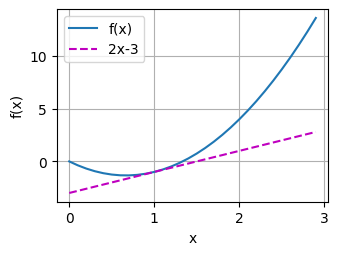

In [10]:
x = np.arange(0, 3, 0.1)
plot(x, [f(x), 2 * x - 3], xlabel='x', ylabel='f(x)', legend=['f(x)', '2x-3'])

In [11]:
# Automatic differentiation is a technique to compute the derivative of a function automatically. 
# It is used in deep learning to compute the gradients of the loss function with respect to the parameters of the model.
x = torch.arange(4.0)
x

tensor([0., 1., 2., 3.])

In [13]:
x.requires_grad_(True)
x.grad #gradient is None because we have not called backward() yet

In [14]:
y = 2 * torch.dot(x, x)
y

tensor(28., grad_fn=<MulBackward0>)

In [15]:
y.backward() #compute the gradient of y with respect to x
x.grad #dy/dx = 4x

tensor([ 0.,  4.,  8., 12.])

In [ ]:
#Gradient of a function with respect to a vector has the same dimension as the vector.

In [16]:
#Gradient needs to be reset to zero
x.grad.zero_()
y = x.sum()
y.backward()
x.grad

tensor([1., 1., 1., 1.])